In [4]:
from spatialdata_io import xenium
import spatialdata as sd
import os
import anndata
import spatialdata_plot
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import squidpy as sq
import pandas as pd

In [5]:
zarr_path = '/Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/data/spatial_data_zarr/'
dirs = [d for d in os.listdir(zarr_path) if d.endswith('.zarr')]
print(dirs)

dt = dict()
for d in dirs:
    #print(os.path.join(zarr_path, f'{d}.zarr'))
    sdata = sd.read_zarr(os.path.join(zarr_path, d))
    dt[d] = sdata

alias_mapping = dict(zip(list(dt.keys()), [i.split("__")[2] for i in list(dt.keys())]))
dt = {alias_mapping.get(k, k): v for k, v in dt.items()}

# From Alice:
# ug-u87 is correct
# ug-utd2 is ug-utd
# ug-utud is correct
# ug-um2-2 is ugum2
#
# ksc-u87 is correct
# KSC-utud is correct
# ug-um2 is actually ksc-um2
# ug-utd is ksc-utd

current_names = ['uG_UM2',
 'uG_UM2-2',
 'uG_UTD-2',
 'uG_UTD',
 'uG_UTUD',
 'KSC_U87',
 'KSC_UTUD',
 'uG_U87']

new_names = ['KSC_UM2',
 'uG_UM2',
 'uG_UTD',
 'KSC_UTD',
 'uG_UTUD',
 'KSC_U87',
 'KSC_UTUD',
 'uG_U87']

alias_mapping = dict(zip(current_names, new_names))

dt = {alias_mapping.get(k, k): v for k, v in dt.items()}

version mismatch: detected: RasterFormatV02, requested: FormatV04


['output-XETG00183__0065698__uG_UM2-2__20250725__192333.zarr', 'output-XETG00183__0065698__uG_U87__20250725__192333.zarr', 'output-XETG00183__0065698__KSC_UTUD__20250725__192333.zarr', 'output-XETG00183__0065698__uG_UTUD__20250725__192333.zarr', 'output-XETG00183__0065698__uG_UTD-2__20250725__192333.zarr', 'output-XETG00183__0065698__KSC_U87__20250725__192333.zarr', 'output-XETG00183__0065698__uG_UM2__20250725__192333.zarr', 'output-XETG00183__0065698__uG_UTD__20250725__192333.zarr']


/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs

In [6]:
merged_dt = sd.concatenate(dt)
merged_dt.write('/Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/data/merged_xenium_sdata.zarr', overwrite=True)

INFO     The SpatialData object is not self-contained (i.e. it contains some elements that are Dask-backed from    
         locations outside                                                                                         
         /Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/data/merged_xenium_sdata.zarr). Please  
         see the documentation of `is_self_contained()` to understand the implications of working with SpatialData 
         objects that are not self-contained.                                                                      
INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/data/merged_xenium_sdata.zarr           


## GeX analysis

In [10]:
adata_dict = dict()

for table_name, table in merged_dt.tables.items():
    adata_dict[table_name] = table

In [11]:
adata = anndata.concat(adata_dict, label="batch", index_unique="-")

In [12]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

In [13]:
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.0008325444244609439
Negative decoding count % : 0.0018403613593347182


<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

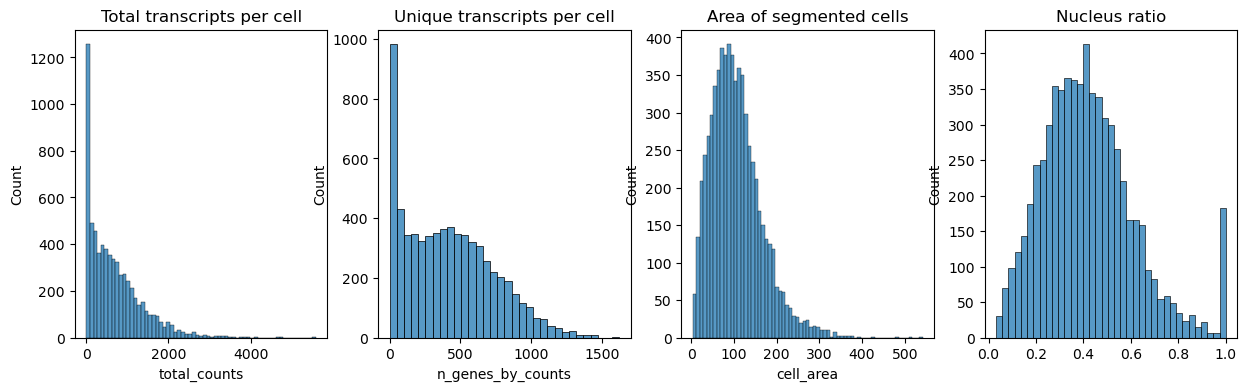

In [14]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

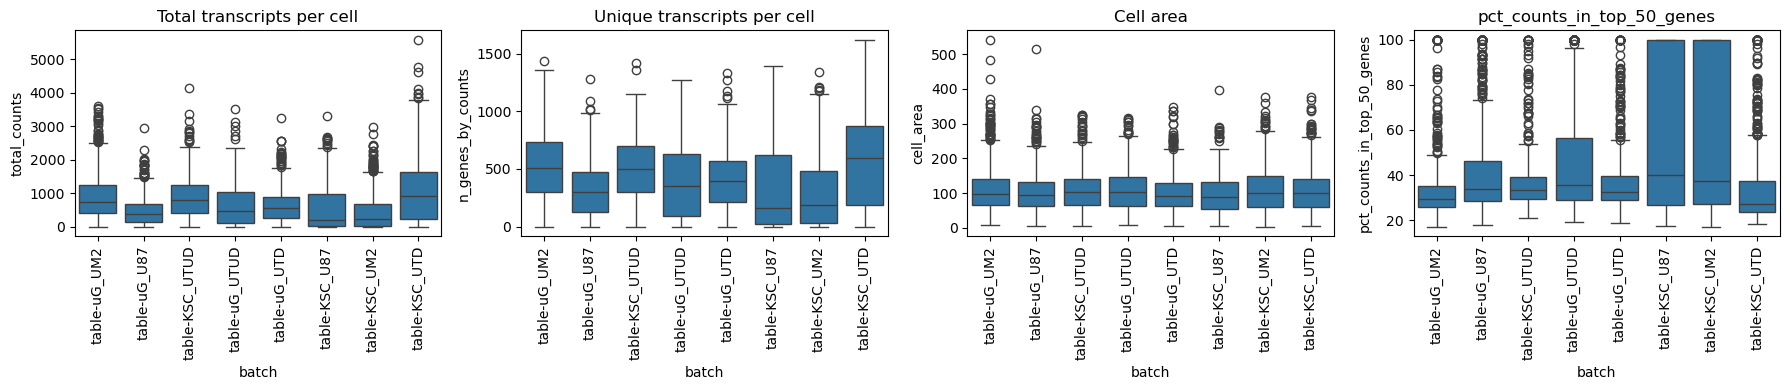

In [15]:
fig, axs = plt.subplots(1, 4, figsize=(18, 4))

sns.boxplot(
    data=adata.obs,
    x="batch",
    y="total_counts",
    ax=axs[0]
)
axs[0].set_title("Total transcripts per cell")
axs[0].tick_params(axis='x', rotation=90)

sns.boxplot(
    data=adata.obs,
    x="batch",
    y="n_genes_by_counts",
    ax=axs[1]
)
axs[1].set_title("Unique transcripts per cell")
axs[1].tick_params(axis='x', rotation=90)

sns.boxplot(
    data=adata.obs,
    x="batch",
    y="cell_area",
    ax=axs[2]
)
axs[2].set_title("Cell area")
axs[2].tick_params(axis='x', rotation=90)

sns.boxplot(
    data=adata.obs,
    x="batch",
    y="pct_counts_in_top_50_genes",
    ax=axs[3]
)
axs[3].set_title("pct_counts_in_top_50_genes")
axs[3].tick_params(axis='x', rotation=90)


plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of cells')

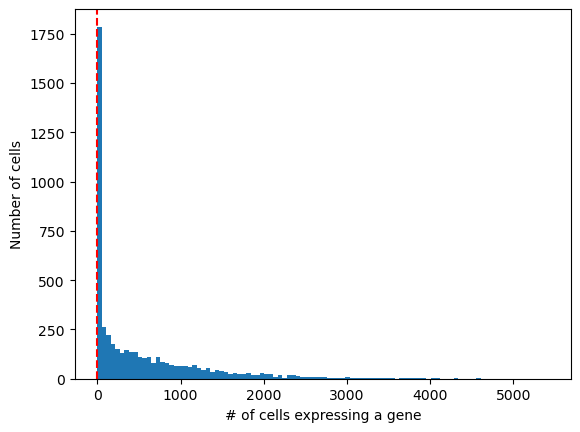

In [16]:
fig = plt.hist(np.sum(adata.X.toarray()>0, axis=0), bins=100)
plt.axvline(x=1, color="r", linestyle="--")  # You can customize color and linestyle
 
plt.xlabel("# of cells expressing a gene")

plt.ylabel("Number of cells")

Text(0, 0.5, 'pct counts in top 50 genes')

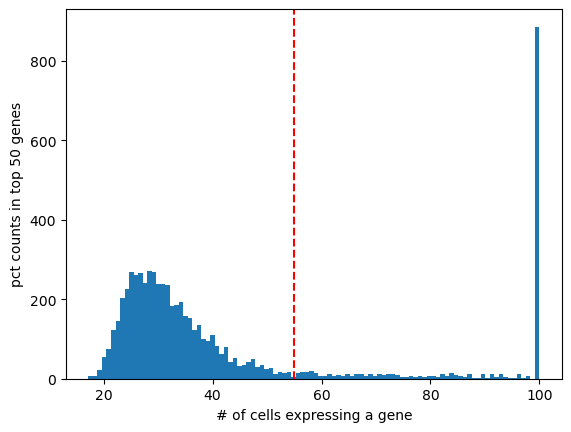

In [17]:
pct_counts_in_top_50_genes_th = 55

fig = plt.hist(adata.obs["pct_counts_in_top_50_genes"], bins=100)
plt.axvline(x=pct_counts_in_top_50_genes_th, color="r", linestyle="--")  # You can customize color and linestyle
 
plt.xlabel("# of cells expressing a gene")

plt.ylabel("pct counts in top 50 genes")

In [18]:
adata = adata[adata.obs["pct_counts_in_top_50_genes"]<pct_counts_in_top_50_genes_th].copy()

In [19]:
sc.pp.filter_genes(adata, min_cells=1)

In [20]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)

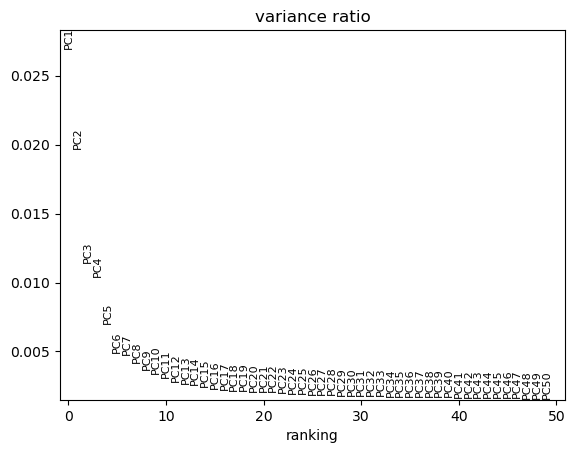

In [21]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=False)

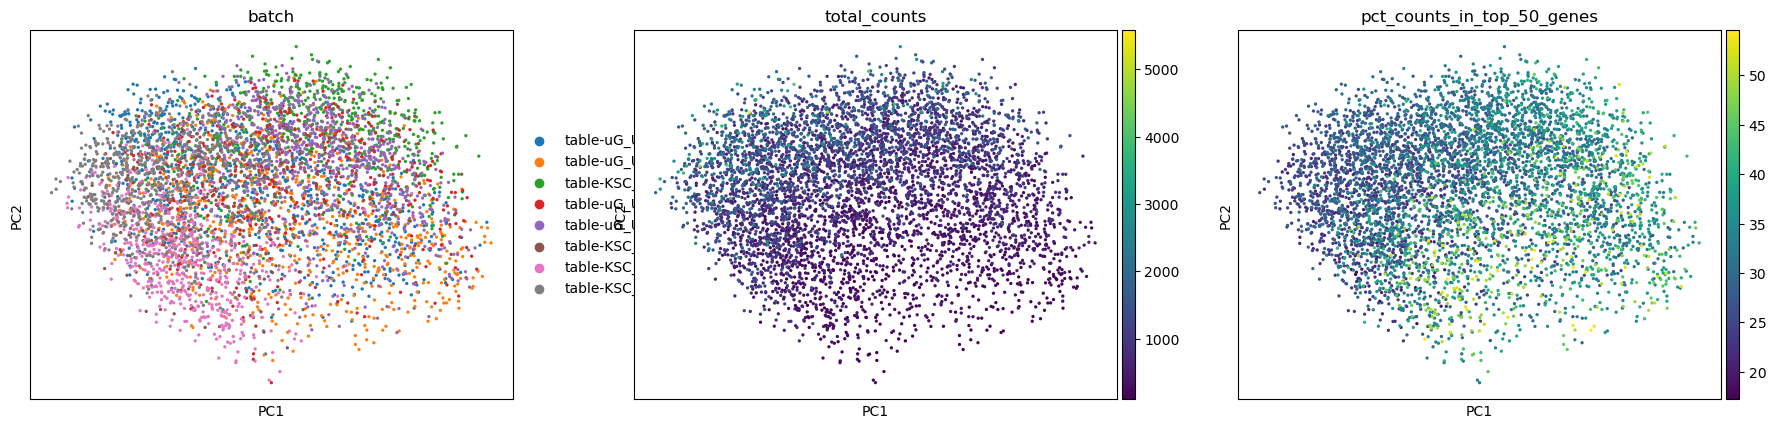

In [22]:
sc.pl.pca(
    adata,
    color=["batch", "total_counts", "pct_counts_in_top_50_genes"]
)

In [23]:
sc.pp.neighbors(adata, n_pcs=6)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.2)

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_4785/993976581.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.2)


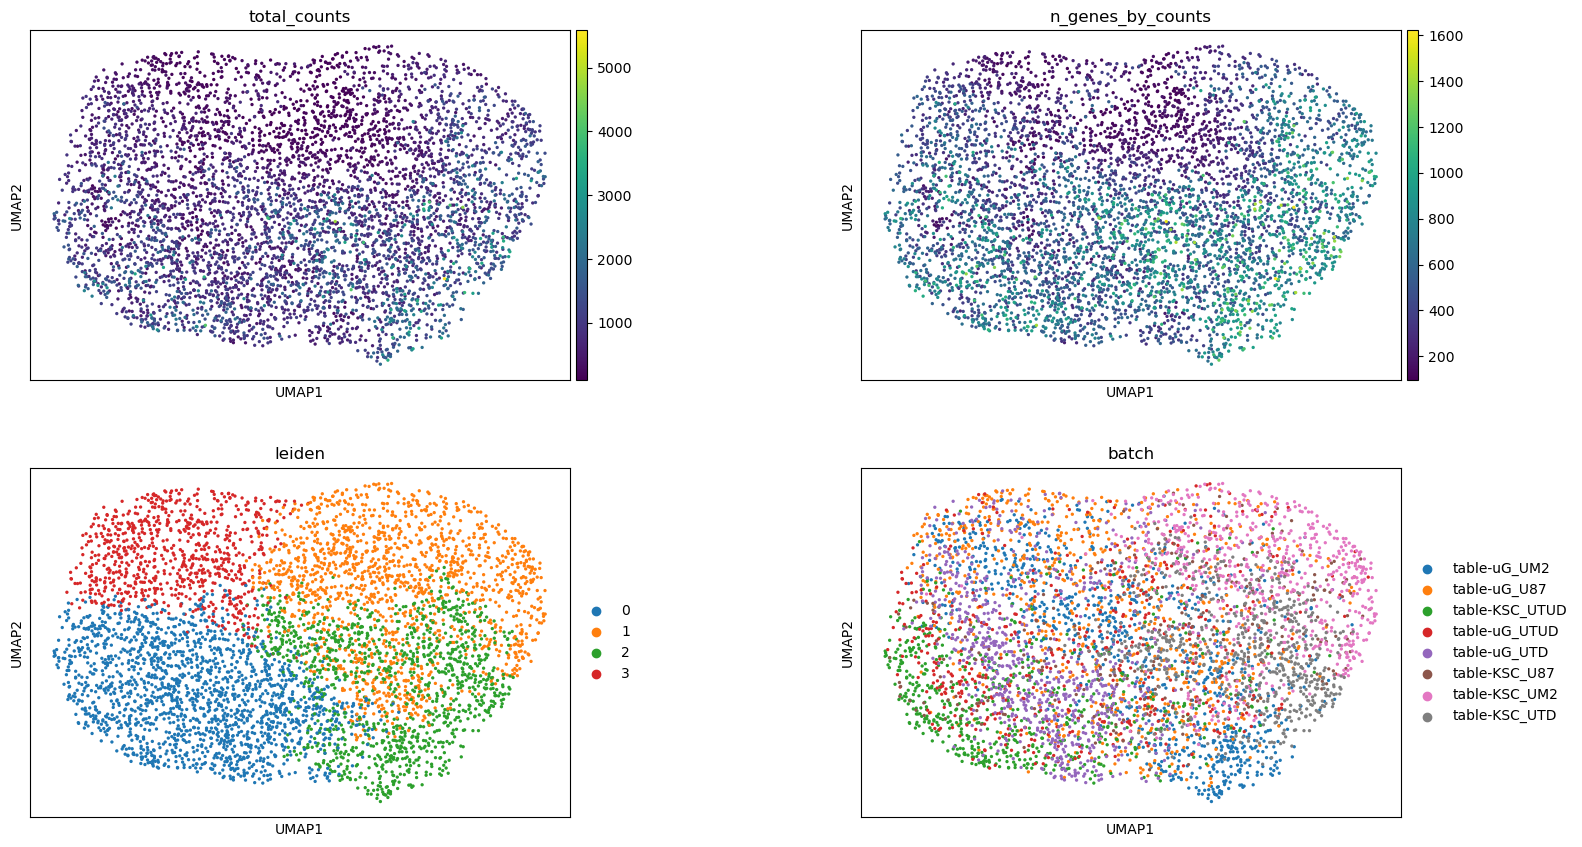

In [24]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
        "batch"
    ],
    ncols=2,
    wspace=0.4,
)

In [25]:
adata.write_h5ad("/Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/data/merged_xenium_sdata.h5ad")

In [26]:
#for table_name in merged_dt.tables.keys():
#    print(len(np.intersect1d(merged_dt.tables[table_name].obs["cell_id"], adata.obs["cell_id"])))